## Loading Raw Data

At the core of ``timesoft``'s tools for working with TIME 
data is the ``timesoft.Timestream`` class, which provides
tools for loading both raw (level 0) data and previously
processed timestream (level 1) data. Here we provide a 
tutorial for using this class to access TIME data files 
and perform some common data processing tasks.

We can get started by loading in some raw data. The
raw data for this demo can be found in ``TIME-analysis/timesandbox/demo/``
in the file ``20220204_mars_focus_1.50.zip``. Unzip this file to
create the ``TIME-analysis/timesandbox/demo/20220204_mars_focus_1.50``
directory.

Then we can import ``Timestream`` and create a ``Timestream``
instance for working with this data. 

(Note: the ``netCDF4`` package
can generate a large number of warnings when loading data. Cells 
in this demo which load raw data often have the IPython magic
``%%capture _`` at the top in order to prevent these messages
from being printed)

In [1]:
%%capture _ 
from timesoft import Timestream

# Load raw data for a focus check on Mars:
path_to_raw_data = "20220204_mars_focus_1.50/"
ts_demo = Timestream(path_to_raw_data,mc=0)

By default, ``Timestream`` inspects the path you provide and attempts
to determine if you are loading raw data (from ``.nc`` netCDF files) 
or processed data (from ``.npz`` files created when data processed 
with ``timesoft`` functionality is saved). In this case, since the 
path specified is a directory and not an ``.npz`` file, it assumes
correctly that we want to import raw data.

Once we have the data loaded we can get some basic information about
it using the ``print`` function:

In [2]:
print(ts_demo)

timesoft.Timestream instance

	source: unknown
	observation: unknown scan type
	detectors in dataset: 960
	samples per detector: 37000 (cleaned data), 37000 (raw data)

current flags:
	stored copy availabe: False
	valid telescope data: True	(coordinates represented in: apparent)
	scans identified: False
	filtering applied: False	(filtering type: none)
	maps constructed: False
	linemaps constructed: False


We see a variety of information about the observation performed, 
the detectors available, and the flags indicating what processing 
has been performed on the dataset so far (none since we just 
loaded the raw data).

In this example, because we're using data from the engineering run
where some header data is missing, a number of fields read 
"unknown". Most of these are not used by the built-in methods,
for ``Timestream``, but they are useful header information to 
have. We'll see how to edit the header information in a moment.

The initialization of ``Timestream`` has a number of tools
for controlling the dataset produced. For example, you can 
see above that our dataset contained information for 960 
detectors - that's every detector in the first spectrometer.
Many of these were not in use during the engineering run, so
loading and working with them all is overkill. You can 
instead specify a list of detectors to load using either
the `xf` parameter (list in feedhorn-frequency coordinates)
or the `cr` parameter (list in readout column-row coordinates).

We can also store an uneditted copy of the data as part
of the ``Timestream`` class using the `store_copy`. This is 
useful for reducing data interactively, as it allows for
resetting the data without reloading the raw data (which
can be slow for large files).

Here we load the data from our Mars observation, restricted
to the detectors in feedhorn 7 and keeping a copy of the
raw data.

In [3]:
%%capture _
# Load only the detectors from the 7th feedhorn:
xf = [(7,f) for f in range(60)]
ts_demo = Timestream(path_to_raw_data,mc=0,xf=xf,store_copy=True)

In [4]:
print(ts_demo)

timesoft.Timestream instance

	source: unknown
	observation: unknown scan type
	detectors in dataset: 60
	samples per detector: 37000 (cleaned data), 37000 (raw data)

current flags:
	stored copy availabe: True
	valid telescope data: True	(coordinates represented in: apparent)
	scans identified: False
	filtering applied: False	(filtering type: none)
	maps constructed: False
	linemaps constructed: False


## Saving and Loading Processed Timestream Data

Once we have done some processing on a timestream
it is useful to save it so we can resume our analysis
at a later time. Additionally it may be useful to
pass off the processed data to someone else or store
the processed data indefinitely. The ``Timestream``
class has a built in format for saving data.

In [5]:
path_to_processed_data = "./"
file_name = "ts_demo.npz"
ts_demo.write(path_to_processed_data+file_name,store_copy=True)

This wrote the timestream data, including all processing applied, to a ``.npz`` file. Since we had only loaded the feedhorn 7 detectors, only those detectors will appear in the saved file. In addition, since we initialized our data with a stored second copy, we can set the `store_copy` parameter of ``Timestream.write`` to True, in order to make that available when we reload the data (we could instead set it to False if we no longer needed the copy and wanted to save space).

We can then reload this data by creating a new timestream instance.

In [6]:
ts_demo = Timestream(path_to_processed_data+file_name,store_copy=True)
print(ts_demo)

timesoft.Timestream instance

	source: unknown
	observation: unknown scan type
	detectors in dataset: 60
	samples per detector: 37000 (cleaned data), 37000 (raw data)

current flags:
	stored copy availabe: True
	valid telescope data: True	(coordinates represented in: apparent)
	scans identified: False
	filtering applied: False	(filtering type: none)
	maps constructed: False
	linemaps constructed: False


We could here have specified not to load the stored copy (``store_copy=False``) or further cut down the detectors by specifying `xf`/`cr`. Note
that if we try to specify a detector not present in the saved data, it will be ignored:

In [7]:
xf = [(6,47),(7,47),(8,47)]
ts_demo = Timestream(path_to_processed_data+file_name,store_copy=True,xf=xf)
print("We requested detectors {}".format(xf))
print("The loaded detectors are {}".format(ts_demo.header['xf_coords']))

We requested detectors [(6, 47), (7, 47), (8, 47)]
The loaded detectors are [(7, 47)]


/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/helpers/_class_bases.py:158: UserWarning: Detector xf=(6, 47) is not in the dataset, skipped when loading
  warnings.warn("Detector {}={} is not in the dataset, skipped when loading".format(det_coord_mode,id))
/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/helpers/_class_bases.py:158: UserWarning: Detector xf=(8, 47) is not in the dataset, skipped when loading
  warnings.warn("Detector {}={} is not in the dataset, skipped when loading".format(det_coord_mode,id))


For the remainder of this demo we will use just the detectors
at frequency index 47. Restricting the data we use
to just these detector will improve the speed of the code.

In [8]:
%%capture _ 
# Detectors we'll use from here on:
xf = [(x,47) for x in range(16)]
ts_demo = Timestream(path_to_raw_data,mc=0,xf=xf,store_copy=True)

## Interacting with the Timestream Data

Now that we have the detectors we want loaded in a
``Timestream`` instance, we can start interacting
with the data. Each ``Timestream`` instance has a few
different attributes where the data is kept. 

First is the header (``Timestream.header``), which 
is a dictionary containing some summary information
about the observation, a listing of the loaded 
detectors, and flags detailing what analysis has
been performed.

To start with, we can see what information is in 
the header:

In [9]:
print(ts_demo.header.keys())

dict_keys(['mc', 'n_detectors', 'n_samples', 'med_time', 'observer', 'object', 'datetime', 'detector_pars', 'scan_pars', 'original_data_path', 'original_files_in', 'filesystem_version', 'xf_coords', 'cr_coords', 'center_ra', 'center_dec', 'epoch', 'filter_type', 'flags'])


Most of the time, the any information from the header is kept
up to date automatically by the built in methods of the ``Timestream``
class. It can be used to recall information about the observation.
For example:

In [10]:
print("ts_demo contains data from an observation of {} conducted by {}".format(ts_demo.header['object'],ts_demo.header['observer']))
print("We currently have {} detectors loaded: xf={}".format(ts_demo.header['n_detectors'],ts_demo.header['xf_coords']))
print("The timestream contains {} samples".format(ts_demo.header['n_samples']))

ts_demo contains data from an observation of unknown conducted by obs
We currently have 16 detectors loaded: xf=[(0, 47) (1, 47) (2, 47) (3, 47) (4, 47) (5, 47) (6, 47) (7, 47) (8, 47)
 (9, 47) (10, 47) (11, 47) (12, 47) (13, 47) (14, 47) (15, 47)]
The timestream contains 37000 samples


Our target is still listed as unknown instead of Mars.
We can fix that using the ``Timestream.header_entry``
method (you can also edit the dictionary directly).
By default, ``Timestream.header_entry`` prevents 
modifications of existing fields to prevent accidental
overwrites of important information. We can disable
this protection, since we know we want to overwrite 
the 'object' information.

In [11]:
ts_demo.header_entry('object','Mars',protect=False)
ts_demo.header_entry('observer','rpk',protect=False)

print("ts_demo contains data from an observation of {} conducted by {}".format(ts_demo.header['object'],ts_demo.header['observer']))
print("We currently have {} detectors loaded: xf={}".format(ts_demo.header['n_detectors'],ts_demo.header['xf_coords']))
print("The timestream contains {} samples".format(ts_demo.header['n_samples']))

ts_demo contains data from an observation of Mars conducted by rpk
We currently have 16 detectors loaded: xf=[(0, 47) (1, 47) (2, 47) (3, 47) (4, 47) (5, 47) (6, 47) (7, 47) (8, 47)
 (9, 47) (10, 47) (11, 47) (12, 47) (13, 47) (14, 47) (15, 47)]
The timestream contains 37000 samples


Data from the telescope and the receiver are recorded in a group 
of time-ordered arrays. If you just want to access the raw data 
you can do so using the attributes:
* ``timestream.t`` - timestamp for each point (taken from the detector data)
* ``timestream.ra`` - RA corresponding to each timestep (taken from the telescope and interpolated to the detector timestamps)
* ``timestream.dec`` - declination corresponding to each timestep (taken from the telescope and interpolated to the detector timestamps)
* ``timestream.az`` - azimuth corresponding to each timestep (taken from the telescope and interpolated to the detector timestamps)
* ``timestream.el`` - telescope elevation corresponding to each timestep (taken from the telescope and interpolated to the detector timestamps)
* ``timestream.tel_flags`` - telescope flag corresponding to each timestep (taken from the telescope and interpolated to the detector timestamps)
* ``timestream.data`` - data for each detector. By default, the data is returned as a 2D array of shape (n_detectors, n_samples). The order of the first index is stored in ``timestream.header['xf_coords']``

To demonstrate, here is a way to visualize the scan pattern of the telescope:

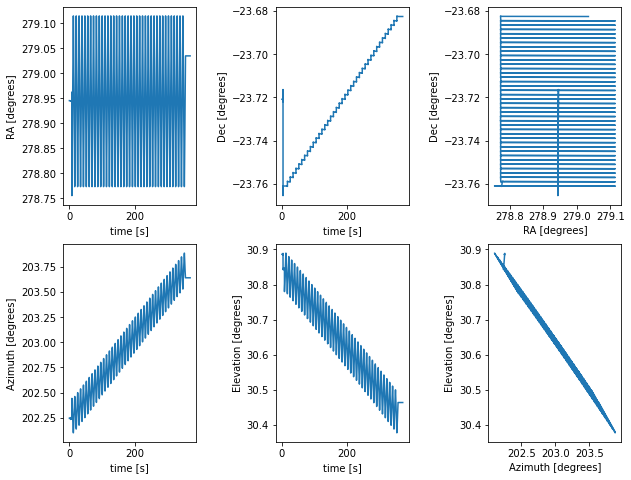

In [12]:
import matplotlib.pyplot as plt

fig,axes = plt.subplots(2,3,figsize=(10,8))
fig.subplots_adjust(wspace=.6)
axes[0,0].set(xlabel='time [s]',ylabel='RA [degrees]')
axes[0,0].plot(ts_demo.t-ts_demo.t[0],ts_demo.ra)
axes[0,1].set(xlabel='time [s]',ylabel='Dec [degrees]')
axes[0,1].plot(ts_demo.t-ts_demo.t[0],ts_demo.dec)
axes[0,2].set(xlabel='RA [degrees]',ylabel='Dec [degrees]')
axes[0,2].plot(ts_demo.ra,ts_demo.dec)

axes[1,0].set(xlabel='time [s]',ylabel='Azimuth [degrees]')
axes[1,0].plot(ts_demo.t-ts_demo.t[0],ts_demo.az)
axes[1,1].set(xlabel='time [s]',ylabel='Elevation [degrees]')
axes[1,1].plot(ts_demo.t-ts_demo.t[0],ts_demo.el)
axes[1,2].set(xlabel='Azimuth [degrees]',ylabel='Elevation [degrees]')
axes[1,2].plot(ts_demo.az,ts_demo.el)

plt.show()

You can see that our map was constructed by using rows of constant 
declination and varrying RA. There is also some data at the begining 
collected while the telescope was moving to its starting location.

Accessing the detector data we want can be a little more tricky,
since any ``Timestream`` instance can have different ordering of the
data. To get around this, there are two helper methods,
``Timestream.get_xf`` and ``Timestream.get_cr`` that 
can determine the location of data for a detector specified in 
xf or cr coordinates respectively.

To plot the detector readout of detector xf=(7,47), we can do the
following:

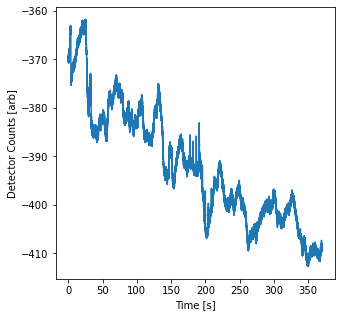

In [13]:
idx = ts_demo.get_xf(7,47)

fig,ax = plt.subplots(figsize=(5,5))
ax.set(xlabel='Time [s]',ylabel='Detector Counts [arb]')
ax.plot(ts_demo.t-ts_demo.t[0],ts_demo.data[idx])
plt.show()

We can zoom in on the region around t=200 seconds, where the regularly spaced peaks correspond to the beam passing over Mars.

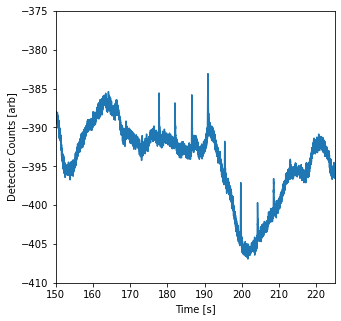

In [14]:
fig,ax = plt.subplots(figsize=(5,5))
ax.set(xlabel='Time [s]',ylabel='Detector Counts [arb]',xlim=(150,225),ylim=(-410,-375))
ax.plot(ts_demo.t-ts_demo.t[0],ts_demo.data[idx])
plt.show()

Note that if you use ``Timestream.get_xf`` or ``Timestream.get_cr``
to request the index of a detector not present in the ``Timestream``
instance, an error will be raised:

In [15]:
idx = ts_demo.get_xf(0,0)

ValueError: xf pair not found

## Processing the Data

The main use of the timestream class is to process timestream 
data for flagging and cleaning. There are many built in features, 
but keep in mind that since timestream is a class, it can be 
extended, and you can create your own class based on it that 
includes additional capabilities.

The analysis methods provided by the timestream class are extensively 
documented, so we won't go into great detail here. The following just 
shows an example of how they can be used to provide some intuition.

We can start by making a map from the data in one of our 
detectors to get an intuition for what is going on. The 
``Timestream.make_map_det`` method quickly maps and plots 
an image of the data from a specified detector. Note that this
is a tool for quickly visualizing the data, more sophisticated
mapping of all detectors comes later in the process.

Making a basic map


/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/gridding_utils.py:161: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  np.add.at(GRID,np.split(data_pos_mod,n,axis=1),np.expand_dims(data_value,1))
/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/timestream_tools.py:1804: RuntimeWarning: invalid value encountered in true_divide
  self.map_det = (grids[:,:,1]/grids[:,:,0]).T


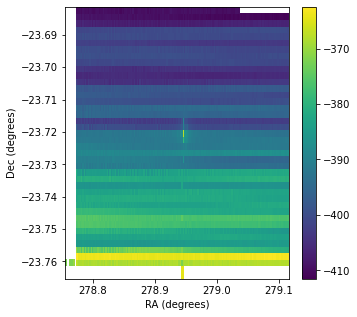

In [16]:
print("Making a basic map")
ts_demo.make_map_det(7,47,pixel=.002,show=True) # Make a quicklook map of xf=(7,47)

This isn't pretty - the vertical streak in the middle is from the initial 
movement of the telescope as it moved to the starting position for the map. 
``Timestream`` has some methods to identify when the telescope is observing
the field in the intended scan pattern and remove data taken at other times.
It can also do a variety of other cleaning tasks:

Identifying Scans
Making a basic map


/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/timestream_tools.py:747: UserWarning: Warning: scan direction is unknown, assuming RA
  warnings.warn("Warning: scan direction is unknown, assuming RA")


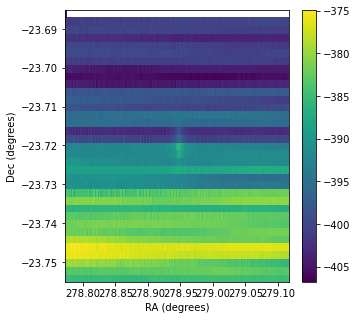

In [17]:
print("Identifying Scans")
ts_demo.remove_obs_flag() # Get rid of points where the telescope wasn't in an "observing" mode
ts_demo.flag_scans() # Identify individual scans across the map
ts_demo.remove_scan_flag() # If data didn't appear to belong to a scan, drop it
ts_demo.remove_short_scans(thresh=100) # Remove anything that appears to short to be a real scan
ts_demo.remove_end_scans(n_start=4,n_finish=4) # Remove the first few scans and last few scans (ie top and bottom of the map)
ts_demo.remove_scan_edge(n_start=5, n_finish=5) # Remove a few data points from the edges of the scan, where the telescope may still be accelerating

print("Making a basic map")
ts_demo.make_map_det(7,47,pixel=.002,show=True) # Make a quicklook map of xf=(7,47)

Now we can at least see Mars (the smudge in the middle), but there are 
streaks across the map that we still don't want. These are caused by 
detector and atmospheric fluctuations. We can filter these out to make 
a better looking map:

Filtering
Making a basic map


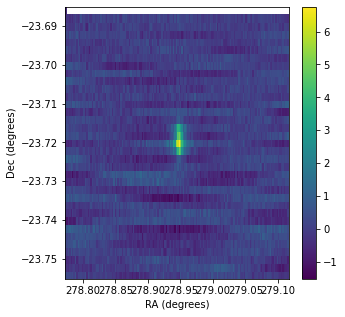

In [18]:
print("Filtering")
ts_demo.filter_scan(n=1) # Remove a 1st degree plynomial from each scan

print("Making a basic map")
ts_demo.make_map_det(7,47,pixel=.002,show=True) # Make a quicklook map of xf=(7,47)

This is a significant improvement. We can see what happened 
by looking at the timestream of the raw data compared to the 
processed data (when they've been saved, the un-editied 
timestream and data are saved as ``Timestream.t_copy`` and 
``Timestream.data_copy``):

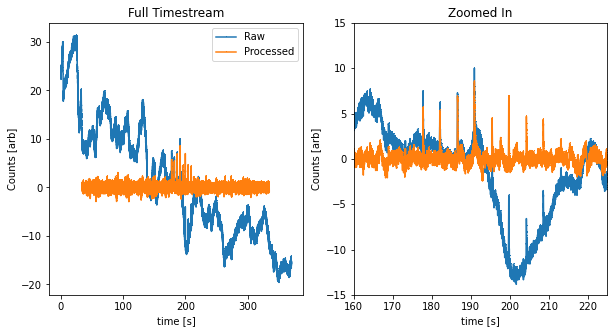

In [19]:
import numpy as np

fig,[ax1,ax2] = plt.subplots(1,2,figsize=(10,5))
ax1.set(xlabel='time [s]',ylabel='Counts [arb]',title='Full Timestream')
ax2.set(xlabel='time [s]',ylabel='Counts [arb]',title='Zoomed In',xlim=(160,225),ylim=(-15,15))
# Plot raw data with median removed to make it easy to compare to the processed data:
ax1.plot(ts_demo.t_copy-ts_demo.t_copy[0],ts_demo.data_copy[ts_demo.get_xf(7,47)]-np.median(ts_demo.data_copy[ts_demo.get_xf(7,47)]),marker=',',label='Raw')
ax2.plot(ts_demo.t_copy-ts_demo.t_copy[0],ts_demo.data_copy[ts_demo.get_xf(7,47)]-np.median(ts_demo.data_copy[ts_demo.get_xf(7,47)]),marker=',',label='Raw')

# Plot the processed data
ax1.plot(ts_demo.t-ts_demo.t_copy[0],ts_demo.data[ts_demo.get_xf(7,47)],marker=',',label='Processed')
ax2.plot(ts_demo.t-ts_demo.t_copy[0],ts_demo.data[ts_demo.get_xf(7,47)],marker=',',label='Processed')

ax1.legend()
plt.show()

The processed timestream still shows some oscillations, but is 
already greatly improved compared to the raw data. For scientific
analysis we will need more careful filtering. But for the time
being, we can play around with the polynomial order we fit to 
each scan to see if that results in further improvements. We'll
reset our data and then re-run our processing with 5th degree 
polynomial filter:

Identifying Scans
Filtering


/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/timestream_tools.py:747: UserWarning: Warning: scan direction is unknown, assuming RA
  warnings.warn("Warning: scan direction is unknown, assuming RA")
/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/timestream_tools.py:1533: UserWarning: Filtering already applied, this filter will be applied on top of previous results
  warnings.warn("Filtering already applied, this filter will be applied on top of previous results")


Making a basic map


/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/gridding_utils.py:161: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  np.add.at(GRID,np.split(data_pos_mod,n,axis=1),np.expand_dims(data_value,1))
/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/timestream_tools.py:1804: RuntimeWarning: invalid value encountered in true_divide
  self.map_det = (grids[:,:,1]/grids[:,:,0]).T


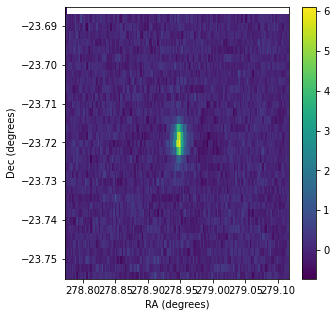

In [20]:
first_degree_filtered = np.copy(ts_demo.data) # Save a copy of the results of the 1st degree filtering
ts_demo.reset() # Then return data to original state, before our processing

print("Identifying Scans")
ts_demo.remove_obs_flag() # Get rid of points where the telescope wasn't in an "observing" mode
ts_demo.flag_scans() # Identify individual scans across the map
ts_demo.remove_scan_flag() # If data didn't appear to belong to a scan, drop it
ts_demo.remove_short_scans(thresh=100) # Remove anything that appears to short to be a real scan
ts_demo.remove_end_scans(n_start=4,n_finish=4) # Remove the first few scans and last few scans (ie top and bottom of the map)
ts_demo.remove_scan_edge(n_start=5, n_finish=5) # Remove a few data points from the edges of the scan, where the telescope may still be accelerating

print("Filtering")
ts_demo.filter_scan(n=5) # Remove a 5th degree plynomial from each scan

print("Making a basic map")
ts_demo.make_map_det(7,47,pixel=.002,show=True) # Make a quicklook map of xf=(7,47)

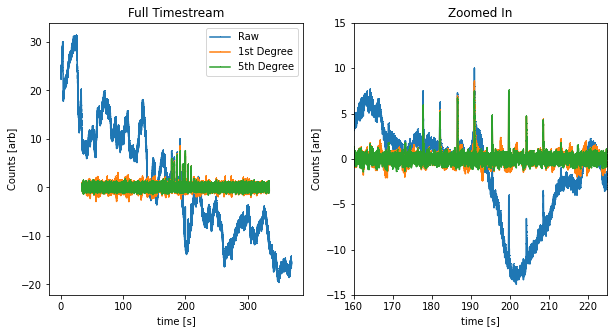

In [21]:
fig,[ax1,ax2] = plt.subplots(1,2,figsize=(10,5))
ax1.set(xlabel='time [s]',ylabel='Counts [arb]',title='Full Timestream')
ax2.set(xlabel='time [s]',ylabel='Counts [arb]',title='Zoomed In',xlim=(160,225),ylim=(-15,15))
# Plot raw data with median removed to make it easy to compare to the processed data:
ax1.plot(ts_demo.t_copy-ts_demo.t_copy[0],ts_demo.data_copy[ts_demo.get_xf(7,47)]-np.median(ts_demo.data_copy[ts_demo.get_xf(7,47)]),marker=',',label='Raw')
ax2.plot(ts_demo.t_copy-ts_demo.t_copy[0],ts_demo.data_copy[ts_demo.get_xf(7,47)]-np.median(ts_demo.data_copy[ts_demo.get_xf(7,47)]),marker=',',label='Raw')

# Plot the old processed data
ax1.plot(ts_demo.t-ts_demo.t_copy[0],first_degree_filtered[ts_demo.get_xf(7,47)],marker=',',label='1st Degree')
ax2.plot(ts_demo.t-ts_demo.t_copy[0],first_degree_filtered[ts_demo.get_xf(7,47)],marker=',',label='1st Degree')

# Plot the processed data
ax1.plot(ts_demo.t-ts_demo.t_copy[0],ts_demo.data[ts_demo.get_xf(7,47)],marker=',',label='5th Degree')
ax2.plot(ts_demo.t-ts_demo.t_copy[0],ts_demo.data[ts_demo.get_xf(7,47)],marker=',',label='5th Degree')

ax1.legend()
plt.show()

## Coordinate Systems

TIME data is natively recorded in "apparent" coordinates,
i.e. the coordinates on the real sky at a given date and 
time where the observations were made. Because these 
coordinates change over time, it is typically useful to
convert data from apparent coordinates to a more 
meaningful system, such as the coordinates where a point
in space would have appeared on January 1, 2000. This
coordinate system is called "J2000", and is the standard
used throughout astronomy for reporting the location of 
sources in the sky.

The current system in which the ``Timestream.ra`` and 
``Timestream.dec`` are represented is saved in the 
header as 'epoch'. To convert our dataset from apparent 
to J2000 coordinates, we can use the 
``Timestream.convert_coordinates`` method:

In [22]:
print("The coordinates for our data were in the '{}' frame".format(ts_demo.header['epoch']))

ts_demo.convert_coordinates('J2000') # Convert to J2000

print("Now they are in the '{}' frame".format(ts_demo.header['epoch']))

The coordinates for our data were in the 'apparent' frame
Now they are in the 'J2000' frame


For our calibration image of Mars, the coordinate system
does not really matter, but for making processing data for
scientific analyses, ensuring the data is in the right 
coordinates is importang. 

To switch back to apparent coordinates, we simply do 
the following:

In [23]:

print("The coordinates for our data were in the '{}' frame".format(ts_demo.header['epoch']))

ts_demo.convert_coordinates('apparent') # Convert to J2000

print("Now they are in the '{}' frame".format(ts_demo.header['epoch']))

The coordinates for our data were in the 'J2000' frame
Now they are in the 'apparent' frame


## Generating Maps

The end goal of a timestream analysis is
often to generate an image of the mapped 
region. Maps, along with one dimensional
'linemaps' are the level 2 data products
of TIME. The ``Timestream`` class can
make these data products and also has 
a shorthand for creating the ``timesoft.Map``
and ``timesoft.LineMap`` objects that are
purpose built for further processing and
analyzing data in this form. To begin 
with, let's generate maps for all of our
detectors:

In [24]:
ts_demo.make_map(pixel=0.002)

/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/gridding_utils.py:161: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  np.add.at(GRID,np.split(data_pos_mod,n,axis=1),np.expand_dims(data_value,1))
/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/timestream_tools.py:1702: RuntimeWarning: invalid value encountered in true_divide
  maps /= grids[:,:,-1].T


This simultaneously maps all of our loaded detectors and creates an
instance of the ``Map`` class, which is stored (for now) as an
attribute of the ``Timestream`` class: ``Timestream.Maps``.

Timestream has a few methods for visualizing mapped data, the primary
one is the ``Timestream.plot_map`` method, which can be used as 
follows:

Map of detector xf=(0, 47)


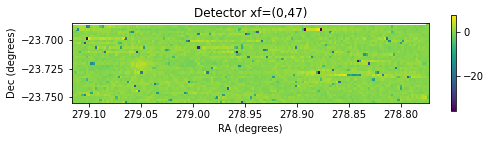

Map of detector xf=(1, 47)


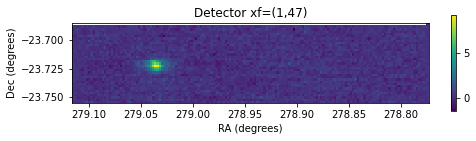

Map of detector xf=(2, 47)


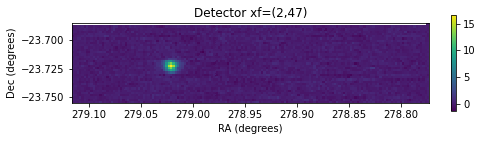

Map of detector xf=(3, 47)


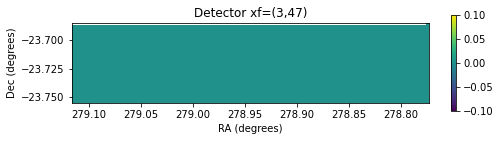

Map of detector xf=(4, 47)


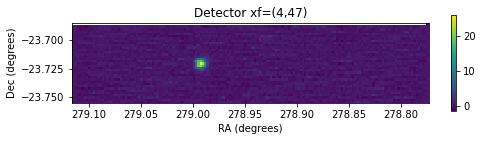

Map of detector xf=(5, 47)


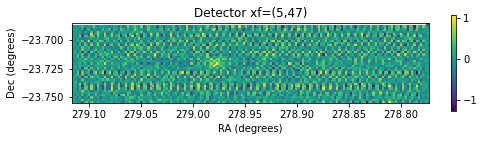

Map of detector xf=(6, 47)


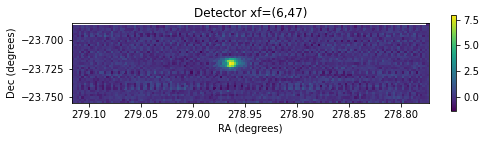

Map of detector xf=(7, 47)


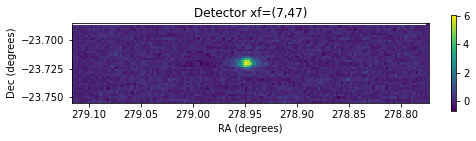

Map of detector xf=(8, 47)


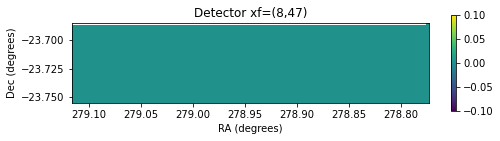

Map of detector xf=(9, 47)


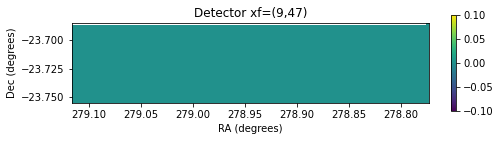

Map of detector xf=(10, 47)


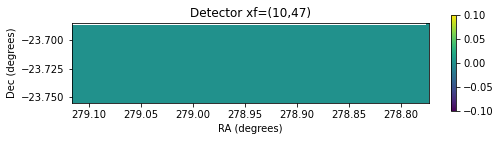

Map of detector xf=(11, 47)


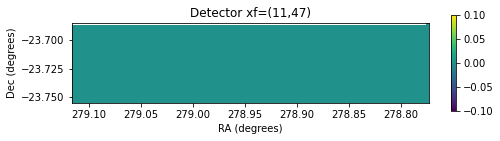

Map of detector xf=(12, 47)


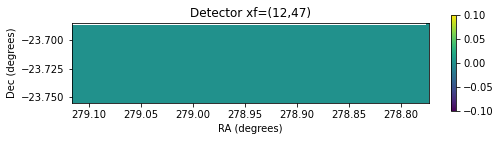

Map of detector xf=(13, 47)


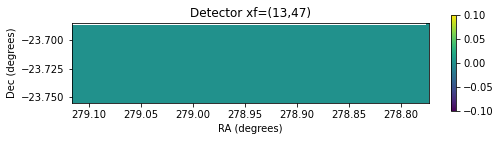

Map of detector xf=(14, 47)


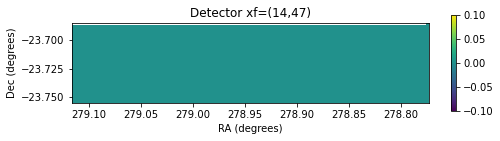

Map of detector xf=(15, 47)


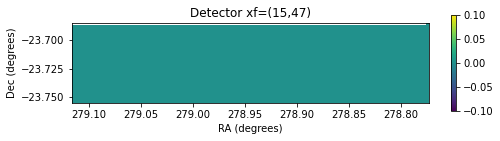

In [25]:
for xf in ts_demo.header['xf_coords']:
    print("Map of detector xf={}".format(xf))
    ts_demo.plot_map(xf[0],xf[1])

Plotting all of our maps, we can see that many detectors are 
turned off completely, a few are reporting data but not responding
to the sky, and about 5 contain images of Mars.

Let's restrict our analysis to just the good detectors. To
do that we use the ``Timestream.restrict_detectors`` method
to specify the detectors we want to keep (note that this
will remove all data for the other detectors for the 
``Timestream`` instance, including any stored copy).

In [26]:
good_detectors = [(1,47),(2,47),(4,47),(6,47),(7,47)]
ts_demo.restrict_detectors(good_detectors,det_coord_mode='xf')

With that, we can plot only our good detectors using the
same code as before. We can noe easily see how Mars moves
across the focal plane in the detectors from five different
feedhorns.

Map of detector xf=(1, 47)


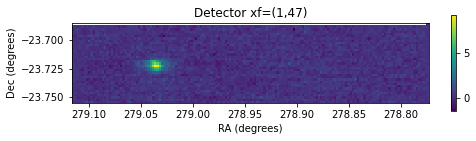

Map of detector xf=(2, 47)


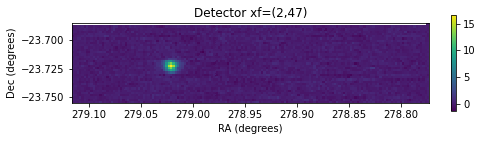

Map of detector xf=(4, 47)


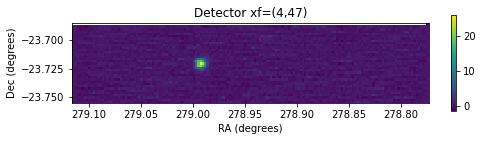

Map of detector xf=(6, 47)


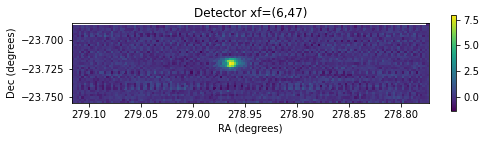

Map of detector xf=(7, 47)


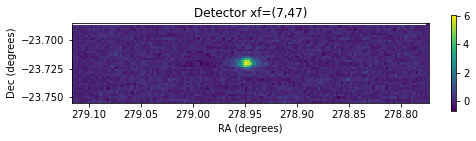

In [27]:
for xf in ts_demo.header['xf_coords']:
    print("Map of detector xf={}".format(xf))
    ts_demo.plot_map(xf[0],xf[1])

Many more map-space analyses are possible, but those are the
purview of tools and documentation for level 2 data. We can leave
off here by saving our maps for additional analysis in the future
with the ``Timestream.write_map`` method:

In [28]:
file_name = "ts_demo_maps.npz"
ts_demo.write_map(path_to_processed_data+file_name)

## Generating Line Maps

Our planned science observations involve making
one dimensional scans back and forth across a 
field. These line scans are often best analyzed
by binning all the samples along a single positional
axis (typically the scan directio). The ``Timestream`` 
class can make these data products using the 
``Timestream.make_1d`` method, which also creates
a ``timesoft.LineMap`` instance, stored in the
``Timestream.LineMaps`` attribute.

Our Mars data is natively in two dimensions, but we
can still analyze it along only the scan direction.
To start with, let's cut our timestream down to only
include declination ranges close to Mars. From the
maps we made earlier, it appears that the flux from
Mars all falls between about -23.73 and -23.71 degrees
in declination.

In [29]:
ts_demo._remove_samples(np.nonzero(ts_demo.dec<-23.71)[0])
ts_demo._remove_samples(np.nonzero(ts_demo.dec>-23.73)[0])

We can verify this worked by remaking our maps and plotting the 
results. Note that doing so will overwrite our old maps, so
if we want to keep whatever maps we've already made, we'll need
to save them before doing this.

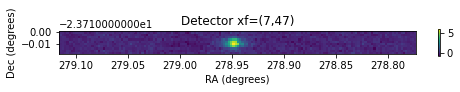

In [30]:
ts_demo.make_map(pixel=0.002)
ts_demo.plot_map(7,47)

That looks good enough for this demonstration. We can now
make our line maps:

In [31]:
ts_demo.make_1d(pixel=.001)

/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/timestream_tools.py:747: UserWarning: Warning: scan direction is unknown, assuming RA
  warnings.warn("Warning: scan direction is unknown, assuming RA")


We can visualize the data for an arbitrary number of
detectors using the ``Timestream.plot_1d`` method. This
method takes a list of detectors to plot and produces
plots of the average counts from each detector as a 
function of position.

Note that our data has not been flux calibrated, and so
the scale for each detector can vary arbitrarily relative
to the others.

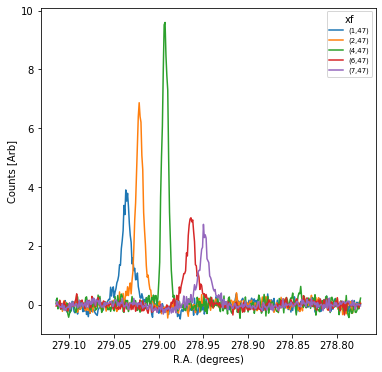

In [32]:

ts_demo.plot_1d(*good_detectors)

Saving our linemaps can be accomplished with the
``Timestream.write_1d`` method:

In [33]:
file_name = "ts_demo_1d.npz"
ts_demo.write_1d(path_to_processed_data+file_name)

## Extending the ``Timestream`` Class

One of the key reasons for construting our data
analysis tools around a set of classes (``Timestream``,
``Map``, ``Linemap``, etc.) is that these objects 
can easily be expanded upon to add additional 
features.

There are many potential cases where it may be useful 
to add features. An immediate need is in the area of
atmospheric corrections, where more sophisticated 
methods for filtering out atmospheric fluctuations are
currently under development. Here we provide a template 
for extending the ``Timestream`` class with a new 
atmospheric filtering method (note that the method
demonstrated here is actually just a simplification
of the current one), to demonstrate how to go about
extending the ``Timestream`` class.

In [34]:
class TimestreamExtension(Timestream):
    def filter_scan_poly_2nd(self):
        """This function iterates through each detector and removes a 2nd degree polynomial from each scan"""

        # Iterate through detectors and channels
        for xf in self.header['xf_coords']:
            index = self.get_xf(xf[0],xf[1])

            # Iterate through each scan
            for i in np.unique(self.scan_flags):
                clean_inds = np.where(self.scan_flags==i)[0] # Determine which samples are part of scan i
                t_mid = np.median(self.t[clean_inds]) # Median time in the scan for centering the polynomial fit

                fit = np.polyfit(self.t[clean_inds]-t_mid, self.data[index][clean_inds], deg=2) # Fit the polynomial
                self.data[index,clean_inds] -= np.polyval(fit,self.t[clean_inds]-t_mid) # Remove from the data


We can now repeat our initial data processing, but 
using the new filtering method. In the following, 
the only changes I make to the scripts used above
are 

1. Replacing ``Timestream`` with ``TimestreamExtension``
   when initializing the class
2. Giving the ``TimestreamExtension`` instance a different
   name, ``ts_ext_demo`` (this is only done so a reference 
   can be kept to ``ts_demo`` for comparing with the revious 
   results)
2. Calling ``ts_ext_demo.filter_scan_poly_2d`` instead of 
   ``ts_demo.filter_scan``

This demonstrates the simplicity of adding new functionality
and modifying pipelines built around the ``Timestream`` class.

In [35]:
%%capture _
# Load only the detectors from the 7th feedhorn:
xf = [(7,f) for f in range(60)]
ts_ext_demo = TimestreamExtension(path_to_raw_data,mc=0,xf=xf,store_copy=True)

Identifying Scans
Filtering


/Users/rpkeenan/Dropbox/4_research/3.1_TIME_analysis/TIME-analysis/timesoft/timestream/timestream_tools.py:747: UserWarning: Warning: scan direction is unknown, assuming RA
  warnings.warn("Warning: scan direction is unknown, assuming RA")


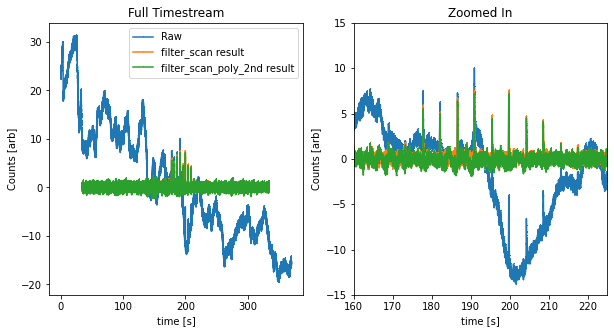

In [36]:
print("Identifying Scans")
ts_ext_demo.remove_obs_flag() # Get rid of points where the telescope wasn't in an "observing" mode
ts_ext_demo.flag_scans() # Identify individual scans across the map
ts_ext_demo.remove_scan_flag() # If data didn't appear to belong to a scan, drop it
ts_ext_demo.remove_short_scans(thresh=100) # Remove anything that appears to short to be a real scan
ts_ext_demo.remove_end_scans(n_start=4,n_finish=4) # Remove the first few scans and last few scans (ie top and bottom of the map)
ts_ext_demo.remove_scan_edge(n_start=5, n_finish=5) # Remove a few data points from the edges of the scan, where the telescope may still be accelerating

print("Filtering")
ts_ext_demo.filter_scan_poly_2nd() # Remove a 2nd degree plynomial from each scan

# Compare the results
fig,[ax1,ax2] = plt.subplots(1,2,figsize=(10,5))
ax1.set(xlabel='time [s]',ylabel='Counts [arb]',title='Full Timestream')
ax2.set(xlabel='time [s]',ylabel='Counts [arb]',title='Zoomed In',xlim=(160,225),ylim=(-15,15))
# Plot raw data with median removed to make it easy to compare to the processed data:
ax1.plot(ts_ext_demo.t_copy-ts_ext_demo.t_copy[0],ts_ext_demo.data_copy[ts_ext_demo.get_xf(7,47)]-np.median(ts_ext_demo.data_copy[ts_ext_demo.get_xf(7,47)]),marker=',',label='Raw')
ax2.plot(ts_ext_demo.t_copy-ts_ext_demo.t_copy[0],ts_ext_demo.data_copy[ts_ext_demo.get_xf(7,47)]-np.median(ts_ext_demo.data_copy[ts_ext_demo.get_xf(7,47)]),marker=',',label='Raw')

# Plot the processed data
ax1.plot(ts_demo.t-ts_demo.t_copy[0],ts_demo.data[ts_demo.get_xf(7,47)],marker=',',label='filter_scan result')
ax2.plot(ts_demo.t-ts_demo.t_copy[0],ts_demo.data[ts_demo.get_xf(7,47)],marker=',',label='filter_scan result')

# Plot the processed data
ax1.plot(ts_ext_demo.t-ts_ext_demo.t_copy[0],ts_ext_demo.data[ts_ext_demo.get_xf(7,47)],marker=',',label='filter_scan_poly_2nd result')
ax2.plot(ts_ext_demo.t-ts_ext_demo.t_copy[0],ts_ext_demo.data[ts_ext_demo.get_xf(7,47)],marker=',',label='filter_scan_poly_2nd result')

ax1.legend()
plt.show()

Having many different classes derived from 
``Timestream`` can be confusing and inefficient. 
If you are developing extensions of the
``Timestream`` class that you believe will be
of general use, you can use this model for 
developing new code, but once you think it is
ready for prime time, you should try to 
integrate it directly into the ``Timestream``
class's source code.